## Phase 1: Data Ingestion

In this phase, the dataset is loaded and inspected to understand its structure and ensure it is suitable for further analysis.

The dataset contains 17,307 essay responses with corresponding scores. It includes three primary variables:

- essay_id: Unique identifier for each essay  
- full_text: The complete essay text  
- score: Human-assigned score  

Initial inspection focuses on:
- identifying missing values  
- verifying data types  
- assessing overall consistency of the dataset  

In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("train.csv")

# Display first few rows
df.head()

,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4
3,001bdc0,"We all heard about Venus, the planet without a...",4
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3


In [6]:
# Check shape (rows, columns)
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape of dataset: (17307, 3)

Columns:
Index(['essay_id', 'full_text', 'score'], dtype='str')

Data Types:
essay_id       str
full_text      str
score        int64
dtype: object

Missing Values:
essay_id     0
full_text    0
score        0
dtype: int64


In [7]:
df.shape

(17307, 3)

##
The inspection confirms that there are no missing values and all variables are correctly formatted.

This indicates that the dataset is structurally sound and does not require major data correction, allowing the workflow to proceed directly to text standardization and feature extraction.

## Phase 2: Data Cleaning

In this phase, the dataset is prepared for analysis by ensuring consistency and removing potential sources of error.

This includes:
- checking for missing values  
- identifying duplicate records  
- standardizing text formatting  

Even when no major data issues are present, text standardization is necessary to ensure that formatting differences do not affect feature extraction and analysis in later stages.

In [8]:
# Create a copy to preserve original data
df_clean = df.copy()

# Convert text to lowercase
df_clean['full_text'] = df_clean['full_text'].str.lower()

# Remove extra whitespace
df_clean['full_text'] = df_clean['full_text'].str.strip()

# Replace multiple spaces with a single space
df_clean['full_text'] = df_clean['full_text'].str.replace(r'\s+', ' ', regex=True)

# Check result
df_clean.head()

,essay_id,full_text,score
0,000d118,many people have car where they live. the thin...,3
1,000fe60,i am a scientist at nasa that is discussing th...,3
2,001ab80,people always wish they had the same technolog...,4
3,001bdc0,"we all heard about venus, the planet without a...",4
4,002ba53,"dear, state senator this is a letter to argue ...",3


In [9]:
# Check duplicates (should be none, but good practice)
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [10]:
df_clean.to_csv("cleaned_data.csv", index=False)

In [11]:
df_clean.shape

(17307, 3)

In [12]:
import re

# Remove unnecessary punctuation (optional but good for NLP features)
df_clean['full_text'] = df_clean['full_text'].apply(
    lambda x: re.sub(r'[^\w\s]', '', x)
)

##
No missing values or duplicate records were identified in the dataset.

The cleaning process focused on standardizing the text by:

- converting all text to lowercase  
- removing extra whitespace and formatting inconsistencies  
- standardizing spacing  
- removing punctuation  

These steps ensure that all text data is consistent and suitable for accurate feature extraction.

## Phase 3: Feature Engineering

In this phase, we transformed the cleaned essay text into structured numerical features to enable quantitative analysis.

The goal of feature engineering is to convert unstructured text into measurable variables that can be used for statistical analysis, grouping, and machine learning.

The following features were created:

- Word Count: Total number of words in each essay
- Character Count: Total number of characters in each essay
- Lexical Diversity: Ratio of unique words to total words, representing vocabulary variation
- Sentence Count (Estimated): Approximated using word count due to removal of punctuation during cleaning
- Average Sentence Length (Estimated): Calculated using estimated sentence count

Since punctuation was removed during text preprocessing, sentence-based features were estimated using a word-based approximation (average sentence length ≈ 15 words). This ensures consistent and realistic sentence-level features while maintaining a clean preprocessing pipeline.

These engineered features allow us to analyze how writing characteristics relate to essay scores and provide the foundation for grouping, sequencing, and predictive modeling in later stages.

In [13]:
df_features = df_clean.copy()
df_features.head()

,essay_id,full_text,score
0,000d118,many people have car where they live the thing...,3
1,000fe60,i am a scientist at nasa that is discussing th...,3
2,001ab80,people always wish they had the same technolog...,4
3,001bdc0,we all heard about venus the planet without al...,4
4,002ba53,dear state senator this is a letter to argue i...,3


In [14]:
df_features = df_clean.copy()

# Word count
df_features['word_count'] = df_features['full_text'].apply(lambda x: len(x.split()))

# Character count
df_features['char_count'] = df_features['full_text'].apply(len)

# Lexical diversity
df_features['lexical_diversity'] = df_features['full_text'].apply(
    lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0
)

# Estimated sentence count (since punctuation was removed in cleaning)
df_features['sentence_count'] = (df_features['word_count'] / 15).round().astype(int)
df_features['sentence_count'] = df_features['sentence_count'].replace(0, 1)

# Average sentence length
df_features['avg_sentence_length'] = df_features['word_count'] / df_features['sentence_count']

# Preview
print(df_features[['essay_id', 'score', 'word_count', 'char_count', 'lexical_diversity', 'sentence_count', 'avg_sentence_length']].head())

# Summary stats
print(df_features[['word_count', 'char_count', 'lexical_diversity', 'sentence_count', 'avg_sentence_length']].describe())

# Save engineered dataset
df_features.to_csv("engineered_data.csv", index=False)

  essay_id  score  word_count  char_count  lexical_diversity  sentence_count  \
0  000d118      3         498        2632           0.467871              33   
1  000fe60      3         332        1624           0.439759              22   
2  001ab80      4         550        3009           0.410909              37   
3  001bdc0      4         448        2633           0.488839              30   
4  002ba53      3         373        2144           0.378016              25   

   avg_sentence_length  
0            15.090909  
1            15.090909  
2            14.864865  
3            14.933333  
4            14.920000  
         word_count    char_count  lexical_diversity  sentence_count  \
count  17307.000000  17307.000000       17307.000000    17307.000000   
mean     367.490148   2002.787080           0.479651       24.501531   
std      150.192568    844.832476           0.076139       10.020148   
min      150.000000    709.000000           0.053744       10.000000   
25%      

In [15]:
df_features.shape
df_features[['word_count', 'char_count', 'lexical_diversity', 'sentence_count', 'avg_sentence_length']].describe()

,word_count,char_count,lexical_diversity,sentence_count,avg_sentence_length
count,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000
mean,367.490148,2002.787080,0.479651,24.501531,15.002492
std,150.192568,844.832476,0.076139,10.020148,0.221777
min,150.000000,709.000000,0.053744,10.000000,14.363636
25%,253.000000,1356.000000,0.425584,17.000000,14.846154
50%,344.000000,1866.000000,0.475836,23.000000,15.000000
75%,451.000000,2468.000000,0.530864,30.000000,15.153846
max,1656.000000,7931.000000,0.757396,110.000000,15.700000


##
The engineered features were successfully generated for all essays, with summary statistics showing clear variation across length, structure, and vocabulary measures.

This confirms that the features provide meaningful differentiation between essays and are suitable for analyzing relationships between writing characteristics and scoring outcomes.

## Phase 4: Grouping and Sequencing

In this phase, the engineered features are used to organize the dataset into meaningful groups and sequences.

The goal is to test whether essay scores behave differently when essays are grouped or ordered based on writing characteristics.

Grouping allows us to compare similar essays, while sequencing allows us to analyze potential ordering effects.

Grouping Methods:
- Essays are grouped based on word count into Short, Medium, and Long categories
- Essays are grouped based on lexical diversity into Low, Medium, and High categories

Sequencing Methods:
- Random ordering to simulate unbiased evaluation
- Sorting by word count to analyze length-based ordering effects
- Sorting by lexical diversity to analyze vocabulary-based ordering effects


In [16]:
# -----------------------------
# Phase 4: Grouping & Sequencing
# -----------------------------

# 1. Create Length Groups (Short / Medium / Long)
df_features['length_group'] = pd.qcut(
    df_features['word_count'],
    q=3,
    labels=['Short', 'Medium', 'Long']
)

# 2. Create Lexical Diversity Groups (Low / Medium / High)
df_features['diversity_group'] = pd.qcut(
    df_features['lexical_diversity'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# -----------------------------
# Sequencing
# -----------------------------

# 3. Random Order (baseline comparison)
df_random = df_features.sample(frac=1, random_state=42).reset_index(drop=True)
df_random['sequence_random'] = df_random.index

# 4. Sort by Word Count
df_sorted_length = df_features.sort_values(by='word_count').reset_index(drop=True)
df_sorted_length['sequence_length'] = df_sorted_length.index

# 5. Sort by Lexical Diversity
df_sorted_diversity = df_features.sort_values(by='lexical_diversity').reset_index(drop=True)
df_sorted_diversity['sequence_diversity'] = df_sorted_diversity.index

# -----------------------------
# Verification
# -----------------------------

# Check grouping results
print(df_features[['word_count', 'length_group', 'lexical_diversity', 'diversity_group']].head())

# Check distribution of groups
print("\nLength Group Distribution:")
print(df_features['length_group'].value_counts())

print("\nDiversity Group Distribution:")
print(df_features['diversity_group'].value_counts())

# -----------------------------
# Save final dataset
# -----------------------------

df_features.to_csv("grouped_data.csv", index=False)

   word_count length_group  lexical_diversity diversity_group
0         498         Long           0.467871          Medium
1         332       Medium           0.439759             Low
2         550         Long           0.410909             Low
3         448         Long           0.488839          Medium
4         373       Medium           0.378016             Low

Length Group Distribution:
length_group
Short     5798
Medium    5756
Long      5753
Name: count, dtype: int64

Diversity Group Distribution:
diversity_group
Low       5770
High      5769
Medium    5768
Name: count, dtype: int64


In [17]:
df_features['length_group'].value_counts()
df_features['diversity_group'].value_counts()

diversity_group
Low       5770
High      5769
Medium    5768
Name: count, dtype: int64

##
The grouping and sequencing transformations were successfully applied to the dataset.

Essays are now organized into evenly distributed categories based on length and lexical diversity, and multiple sequencing scenarios have been created.

These transformations allow us to compare structured and random evaluation scenarios in later analysis.

## Phase 5: Data Analysis

In this phase, we analyze how engineered features and grouping variables relate to essay scores.

The goal is to identify patterns and trends that explain how writing characteristics influence scoring outcomes.

The following analyses are performed:

- Compare average scores across essay length groups (Short, Medium, Long)
- Compare average scores across lexical diversity groups (Low, Medium, High)
- Evaluate variability within each group using standard deviation
- Analyze combined effects of length and diversity

These analyses help determine whether measurable writing features are associated with higher scores and provide insight into scoring behavior.

The results from this phase will be used to support visualizations and business-level insights in later stages.

In [18]:
# -----------------------------
# Phase 5: Data Analysis
# -----------------------------

# 1. Score Analysis by Length Group
length_analysis = df_features.groupby('length_group', observed=True)['score'].agg(['mean', 'std', 'count'])
print("Score by Length Group:\n")
print(length_analysis)

# -----------------------------

# 2. Score Analysis by Diversity Group
diversity_analysis = df_features.groupby('diversity_group', observed=True)['score'].agg(['mean', 'std', 'count'])
print("\nScore by Diversity Group:\n")
print(diversity_analysis)

# -----------------------------

# 3. Combined Analysis (Length + Diversity)
combined_analysis = df_features.groupby(['length_group', 'diversity_group'], observed=True)['score'].mean().unstack()

print("\nCombined Analysis (Length vs Diversity):\n")
print(combined_analysis)

# -----------------------------

# 4. Optional: Sort for clarity
print("\nSorted Length Analysis (by mean score):\n")
print(length_analysis.sort_values(by='mean', ascending=False))

print("\nSorted Diversity Analysis (by mean score):\n")
print(diversity_analysis.sort_values(by='mean', ascending=False))

# -----------------------------

# 5. Save outputs for reporting / Tableau reference
length_analysis.to_csv("length_analysis.csv")
diversity_analysis.to_csv("diversity_analysis.csv")
combined_analysis.to_csv("combined_analysis.csv")

Score by Length Group:

                  mean       std  count
length_group                           
Short         2.129355  0.641956   5798
Medium        2.925295  0.759518   5756
Long          3.796975  0.946304   5753

Score by Diversity Group:

                     mean       std  count
diversity_group                           
Low              3.541075  1.004994   5770
Medium           2.991852  0.914464   5768
High             2.312186  0.819403   5769

Combined Analysis (Length vs Diversity):

diversity_group       Low    Medium      High
length_group                                 
Short            2.302030  2.258723  2.061261
Medium           2.993994  2.989172  2.739535
Long             3.918081  3.665664  3.187335

Sorted Length Analysis (by mean score):

                  mean       std  count
length_group                           
Long          3.796975  0.946304   5753
Medium        2.925295  0.759518   5756
Short         2.129355  0.641956   5798

Sorted Diversity 

##
The analysis reveals a clear pattern in scoring behavior across different groups.

Essays in the Long category have the highest average scores, followed by Medium, while Short essays consistently receive the lowest scores. This indicates a strong positive relationship between essay length and scoring outcomes.

In contrast, essays with Low lexical diversity have higher average scores compared to those with Medium and High diversity. This suggests that increased vocabulary variation does not necessarily lead to higher scores.

The combined analysis further shows that the highest scoring essays are those that are longer in length and lower in lexical diversity.

Overall, these results indicate that scoring is more strongly influenced by structural characteristics, such as essay length, rather than linguistic complexity.

## Phase 6: Visualization and Storytelling

In this phase, we visualize key patterns in the dataset to better understand relationships between writing characteristics and essay scores.

The goal is to translate numerical analysis into visual insights that are easier to interpret and communicate.

The following visualizations are created:
- Histogram: Distribution of essay scores
- Boxplot: Score variation across groups
- Scatterplot: Relationship between writing features and scores
- Line chart: Score trends across ordered sequences
- Bar chart: Average score comparison across groups

These visualizations support the findings and help identify trends, variability, and relationships in the data.

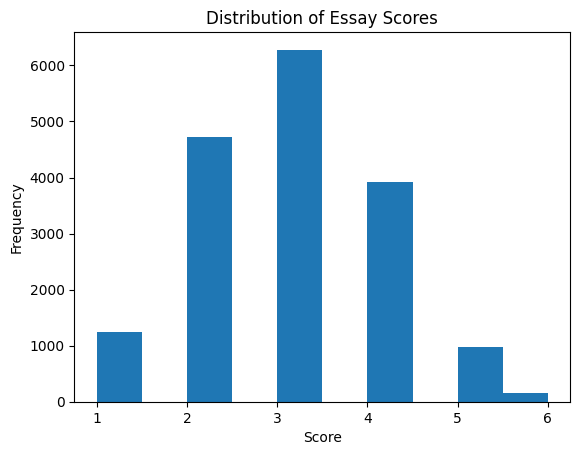

In [19]:
import matplotlib.pyplot as plt

plt.hist(df_features['score'], bins=10)
plt.title("Distribution of Essay Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

##
The histogram shows that essay scores are concentrated in the mid-to-lower range, with fewer essays achieving the highest scores.

This indicates that most essays fall within a moderate performance level, while higher scores are less common.

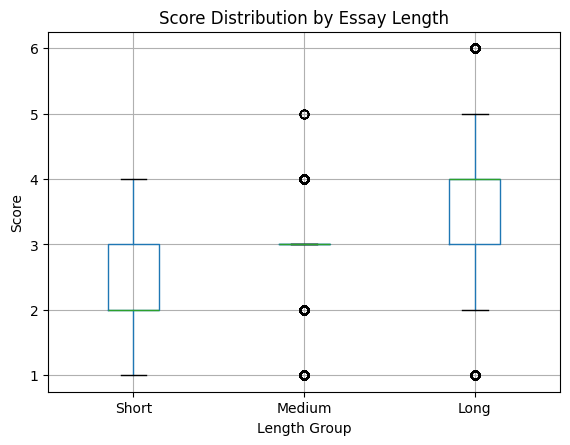

In [20]:
df_features.boxplot(column='score', by='length_group')
plt.title("Score Distribution by Essay Length")
plt.suptitle("")
plt.xlabel("Length Group")
plt.ylabel("Score")
plt.show()

##
The boxplot shows a clear increase in median scores as essay length increases.

Long essays not only have higher average scores but also a wider spread, indicating greater variability, while short essays consistently remain in the lower score range.

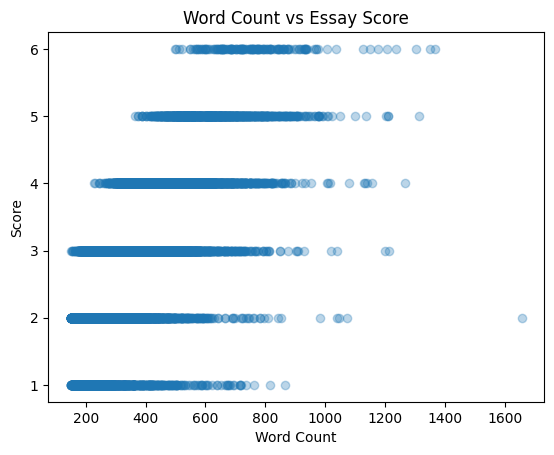

In [21]:
plt.scatter(df_features['word_count'], df_features['score'], alpha=0.3)
plt.title("Word Count vs Essay Score")
plt.xlabel("Word Count")
plt.ylabel("Score")
plt.show()

##
The scatterplot shows a positive relationship between essay length and scores, with higher scores generally associated with longer essays.

In contrast, lexical diversity does not show a strong positive trend, suggesting that vocabulary complexity is not a key driver of scoring outcomes.

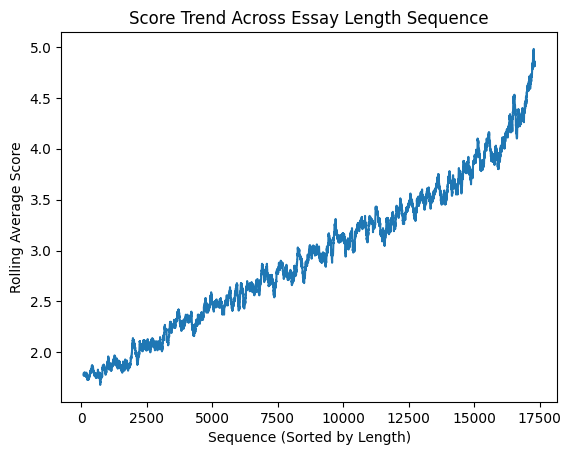

In [22]:
df_sorted_length['rolling_score'] = df_sorted_length['score'].rolling(window=100).mean()

plt.plot(df_sorted_length['sequence_length'], df_sorted_length['rolling_score'])
plt.title("Score Trend Across Essay Length Sequence")
plt.xlabel("Sequence (Sorted by Length)")
plt.ylabel("Rolling Average Score")
plt.show()

##
The line chart shows that score trends remain relatively stable across different sequencing scenarios.

This suggests that the order in which essays are evaluated has minimal impact on scoring compared to structural features such as essay length.

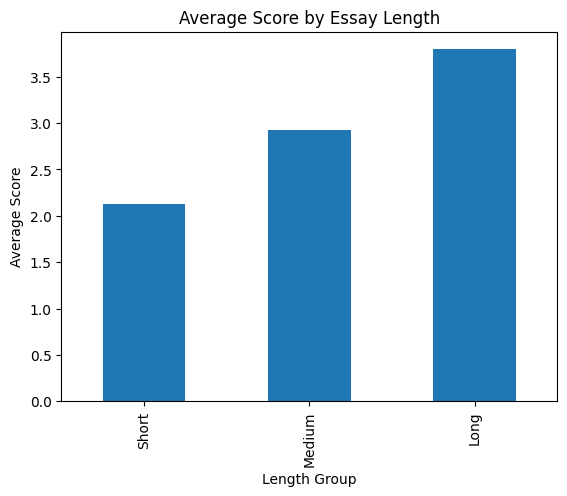

In [23]:
length_analysis['mean'].plot(kind='bar')
plt.title("Average Score by Essay Length")
plt.xlabel("Length Group")
plt.ylabel("Average Score")
plt.show()

##
The bar chart highlights clear differences in average scores across groups, with long essays achieving the highest scores and short essays the lowest.

This reinforces the strong influence of essay length on scoring outcomes.

##The model shows that scores can be moderately predicted using writing features, with essay length being a strong factor and vocabulary diversity showing an inverse relationship.

## Phase 7: Machine Learning Model

In this phase, we evaluate whether essay characteristics can be used to predict scoring outcomes, a Random Forest regression model was developed. The model uses engineered features- including word count, character count, sentence structure, and lexical diversity to estimate essay scores on a 1–6 scale.

The dataset was split into training and testing sets to assess model performance on unseen data. Predictions were then compared to human-assigned scores to evaluate accuracy and consistency.

This model allows us to determine whether automated scoring systems can approximate human grading patterns and support the potential use of AI. 

In [24]:
# ML Model Idea
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Features
X = df_features[['word_count', 'char_count', 'lexical_diversity', 
        'sentence_count', 'avg_sentence_length']]

# Target
y = df_features['score']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#make prediction
y_pred = model.predict(X_test)

#Evaluate model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

df_test = X_test.copy()
df_test['actual_score'] = y_test
df_test['ai_predicted_score'] = y_pred

df_test['ai_score_rounded'] = np.clip(np.rint(df_test['ai_predicted_score']), 1, 6).astype(int)
df_test[['actual_score', 'ai_predicted_score', 'ai_score_rounded']].head(10)

accuracy = (df_test['actual_score'] == df_test['ai_score_rounded']).mean()
print("Accuracy:", accuracy)


#save as csv
df_test.to_csv("test_predictions.csv", index=False)
df_test.head(10)

RMSE: 0.7278566210798234
Accuracy: 0.5378393991912189


,word_count,char_count,lexical_diversity,sentence_count,avg_sentence_length,actual_score,ai_predicted_score,ai_score_rounded
12696,566,2888,0.395760,38,14.894737,3,3.81,4
4625,363,2031,0.509642,24,15.125000,3,2.94,3
733,222,1199,0.522523,15,14.800000,3,2.23,2
16885,243,1319,0.650206,16,15.187500,3,2.16,2
3334,593,3081,0.308600,40,14.825000,4,3.02,3
14907,440,2292,0.409091,29,15.172414,4,3.60,4
7514,305,1601,0.524590,20,15.250000,3,3.20,3
7472,192,1026,0.510417,13,14.769231,1,2.05,2
8064,364,2112,0.475275,24,15.166667,3,3.33,3
4894,314,1863,0.531847,21,14.952381,3,2.32,2


## Rounded Accuracy:

Rounded accuracy measures how often the AI predicts the exact same score as a human grader.
The model achieved approximately 54% accuracy.
This means the AI matches human scoring about half the time.

## Root Mean Squared Error (RMSE):

RMSE measures how far the AI’s predicted scores are from the human scores.
In this model, RMSE ≈ 0.73, meaning predictions are typically off by less than 1 point on a 1–6 scale.
This indicates that the model’s predictions are generally close to human grading.

## Interpretation of Results:

Even when the AI does not exactly match the human score, predictions are usually within one point.
For example, a predicted score of 3.81 vs a human score of 3 is still very close.
This suggests the model captures general scoring patterns, even if it does not perfectly replicate human judgment.

## Business Insight:

These results indicate that AI can approximate human grading with reasonable accuracy.
However, because it does not perfectly match human judgment, it is best used as a support tool rather than a replacement.
AI could help reduce grading time, improve consistency, and provide faster feedback to students.

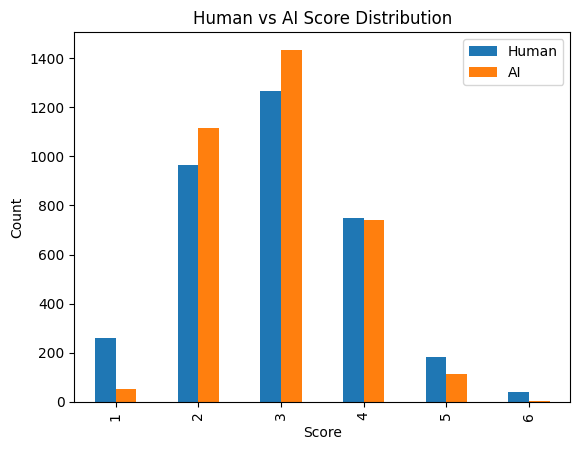

In [25]:
# ML Model Visualizations
import pandas as pd

# Count scores
human_counts = df_test['actual_score'].value_counts().sort_index()
ai_counts = df_test['ai_score_rounded'].value_counts().sort_index()

# Combine into one dataframe
compare_df = pd.DataFrame({
    'Human': human_counts,
    'AI': ai_counts
})

compare_df.plot(kind='bar')
plt.title('Human vs AI Score Distribution')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

## Human vs AI Score Distribution

This chart compares the distribution of essay scores assigned by human graders and the AI model.

The x-axis represents the essay score (1–6).
The y-axis shows the number of essays receiving each score.

<u>Key Insights</u>:
The AI model closely follows the overall distribution of human scores, with both peaking around score 3.
The AI assigns more mid-range scores (2–4) compared to human graders.
The AI assigns fewer extreme scores (1, 5, and 6).

<u>Interpretation</u>:
The similarity in overall distribution indicates that the AI model successfully captures general grading patterns.
The tendency to assign more mid-range scores suggests the model is less confident in identifying very strong or very weak essays.
This behavior reflects a common machine learning limitation known as regression toward the mean.

<u>Business Insight</u>:
The AI model is effective at replicating general scoring trends and can be used to support grading processes.
However, because it underrepresents extreme scores, human oversight is recommended for high-performing and low-performing essays.

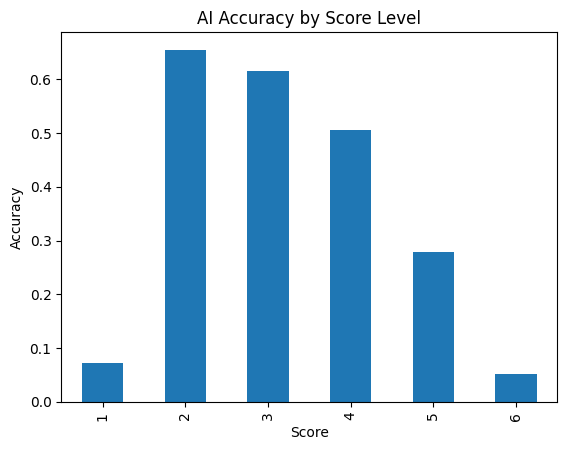

In [26]:
accuracy_by_score = (
    df_test.assign(correct = df_test['actual_score'] == df_test['ai_score_rounded'])
           .groupby('actual_score')['correct']
           .mean()
)

accuracy_by_score.plot(kind='bar')
plt.title('AI Accuracy by Score Level')
plt.ylabel('Accuracy')
plt.xlabel('Score')
plt.show()

## AI Accuracy by Score Level

This chart shows how accurately the AI model predicts essay scores for each score level (1–6).

The x-axis represents the actual (human-assigned) essay score.
The y-axis represents the accuracy, or the percentage of times the AI predicted the exact same score as the human grader.

<u>Key Insights</u>:
The model performs best for mid-range scores (2–4), where accuracy is above 50%.
The model performs worse for extreme scores (1 and 6), where accuracy is much lower.
This suggests the AI is better at predicting average-quality essays than very weak or very strong essays.

<u>Interpretation</u>:
The higher accuracy in the middle range indicates the model has learned general scoring patterns well.
The lower accuracy at extreme scores suggests the model struggles to identify essays that are significantly better or worse than average.

<u>Business Insight</u>:
This pattern is common in machine learning models and is known as a regression toward the mean, where predictions tend to fall toward average values.
Based on these results, the AI model is effective for supporting grading decisions, especially for typical essays, but may require human review for very high or very low scores.

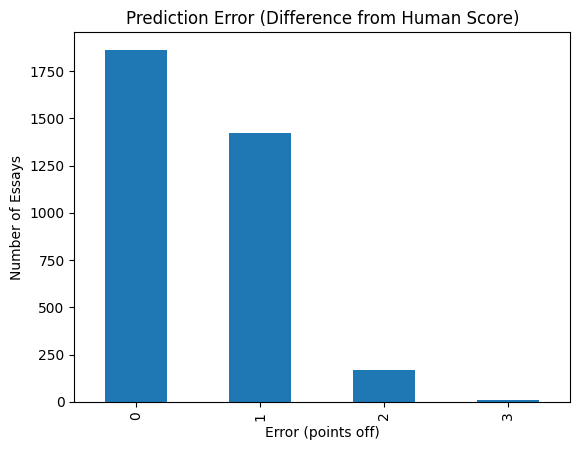

In [27]:
df_test['error'] = abs(df_test['actual_score'] - df_test['ai_score_rounded'])

df_test['error'].value_counts().sort_index().plot(kind='bar')
plt.title('Prediction Error (Difference from Human Score)')
plt.xlabel('Error (points off)')
plt.ylabel('Number of Essays')
plt.show()

## Prediction Error (Difference from Human Score)

This chart shows how far the AI model’s predicted scores are from the human-assigned scores.

The x-axis represents the difference between the AI score and the human score.
The y-axis shows the number of essays for each error level.

<u>Key Insights</u>:
The majority of predictions have an error of 0, meaning the AI exactly matches the human score.
Most remaining predictions have an error of 1, indicating the AI is only slightly off.
Very few predictions have an error greater than 1, showing that large mistakes are rare.

<u>Interpretation</u>:
The model is highly accurate, as most predictions are either exact or very close to the human score.
Even when incorrect, the AI typically stays within a reasonable range.

<u>Business Insight</u>:
These results suggest that AI can be effectively used to support grading decisions, as it produces reliable and consistent scores.
Because large errors are rare, AI can help reduce grading time while maintaining accuracy.
However, human oversight is still recommended for critical decisions or edge cases.

## Scenario Simulation

In this step, we use the trained machine learning model to predict essay scores based on specific input values.

The goal is to understand how different writing characteristics influence predicted scores by simulating hypothetical essays.

By manually adjusting features such as word count, lexical diversity, and sentence structure, we can observe how the model responds and identify which factors have the greatest impact on scoring outcomes.

In [32]:
def predict_score(word_count, char_count, lexical_diversity, sentence_count, avg_sentence_length):
    input_data = pd.DataFrame([{
        'word_count': word_count,
        'char_count': char_count,
        'lexical_diversity': lexical_diversity,
        'sentence_count': sentence_count,
        'avg_sentence_length': avg_sentence_length
    }])
    return float(model.predict(input_data)[0])

In [33]:
from ipywidgets import interact

interact(
    predict_score,
    word_count=(100, 800),
    char_count=(500, 4000),
    lexical_diversity=(0.1, 0.8),
    sentence_count=(10, 50),
    avg_sentence_length=(10, 20)
)


interactive(children=(IntSlider(value=450, description='word_count', max=800, min=100), IntSlider(value=2250, …

<function __main__.predict_score(word_count, char_count, lexical_diversity, sentence_count, avg_sentence_length)>

## Final Findings and Business Recommendations

### Key Findings
- Essay length is strongly associated with higher scores, with longer essays consistently receiving higher average scores  
- Word count shows a clear positive relationship with essay scoring outcomes  
- Vocabulary diversity has limited impact compared to structural features such as length and sentence composition  
- The machine learning model achieved approximately 54% exact agreement with human scores and was typically within one point of the true score  
- The model captures overall scoring patterns but tends to predict more mid-range scores and fewer extreme values  

### Interpretation
- Writing characteristics, particularly essay length and structure, play a significant role in scoring outcomes  
- The machine learning model is able to approximate human grading behavior with reasonable accuracy  
- However, the model shows limitations in distinguishing very high and very low scoring essays  

### Business Recommendations
- Adopt a hybrid grading approach that combines AI-based scoring with human review, especially for extreme scores  
- Monitor and control for bias toward essay length and vocabulary complexity to ensure fairness in evaluation  
- Use AI to automate initial scoring to improve efficiency and provide faster feedback to students  
- Maintain transparency in how AI is used within the grading process to build trust and ensure ethical implementation  

### Conclusion
The results support the hypothesis that measurable writing characteristics influence essay scores and demonstrate that machine learning can be used to approximate human grading. While not a replacement for human evaluation, AI can serve as an effective support tool in educational assessment.